# Example 15: Knot unsupervised

In [15]:
import pandas as pd
import numpy as np
import torch
from kan import *
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')
print(device)

seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

dtype = torch.get_default_dtype()

# Download data: https://colab.research.google.com/github/deepmind/mathematics_conjectures/blob/main/knot_theory.ipynb#scrollTo=l10N2ZbHu6Ob
# pip install pandas gcsfs
df = pd.read_csv("https://storage.googleapis.com/maths_conjectures/knot_theory/knot_theory_invariants.csv")
df.keys()

#A# also normalize X, why twice??
X = df[df.keys()[1:]].to_numpy()
"""mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean[np.newaxis,:])/std[np.newaxis,:]"""

# normalize X
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean[np.newaxis,:])/X_std[np.newaxis,:]
input_normalier = [X_mean, X_std]

dataset = {}
num = X.shape[0]
n_feature = X.shape[1]
train_ratio = 0.8
train_id_ = np.random.choice(num, int(num*train_ratio), replace=False)
test_id_ = np.array(list(set(range(num))-set(train_id_)))
dataset['train_input'] = torch.from_numpy(X[train_id_]).type(dtype)
dataset['test_input'] = torch.from_numpy(X[test_id_]).type(dtype)

def construct_contrastive_dataset(tensor):
    """
    construct contrastive dataset by randomly permuting each column of the input tensor independently.
    """
    y = copy.deepcopy(tensor)
    for i in range(y.shape[1]):
        y[:,i] = y[:,i][torch.randperm(y.shape[0])]
    return y

# negative sample
dataset['contrastive_train_input'] = construct_contrastive_dataset(dataset['train_input'])
dataset['contrastive_test_input'] = construct_contrastive_dataset(dataset['test_input'])

dataset['train_label'] = torch.cat([torch.ones(dataset['train_input'].shape[0],1), torch.zeros(dataset['contrastive_train_input'].shape[0],1)], dim=0).to(device)
dataset['train_input'] = torch.cat([dataset['train_input'], dataset['contrastive_train_input']], dim=0).to(device)

dataset['test_label'] = torch.cat([torch.ones(dataset['test_input'].shape[0],1), torch.zeros(dataset['contrastive_test_input'].shape[0],1)], dim=0).to(device)
dataset['test_input'] = torch.cat([dataset['test_input'], dataset['contrastive_test_input']], dim=0).to(device)


cuda


In [16]:
def train_acc():
    return torch.mean(((model(dataset['train_input']) > 0.5) == dataset['train_label']).float())

def test_acc():
    return torch.mean(((model(dataset['test_input']) > 0.5) == dataset['test_label']).float())

#A# 18,1,1
model = KAN(width=[n_feature,1,1], grid=5, k=3, seed=seed, device=device)

#A# second layer to be gaussian function with a peek one centered at zero
#A# positive example will have activation around 0, letting g(x) = 0
#A# x: features, g():activation function
model.fix_symbolic(1,0,0,'gaussian',fit_params_bool=False)

# lamb = [0.01, 0.001], seed = {0,1,2,...,99}
model.fit(dataset, lamb=0.001, batch=1024, metrics=[train_acc, test_acc], display_metrics=['train_loss', 'reg', 'train_acc', 'test_acc']);

checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

 train_loss: nan | reg: nan | train_acc: 5.00e-01 | test_acc: 5.00e-01 |: 100%|█| 100/100 [00:57<00:

saving model version 0.2


In [13]:
# for plotting error
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
import matplotlib.axes._axes as _axes

_cls = model.__class__

# reset if previously patched
if hasattr(_cls, "_orig_plot"):
    _cls.plot = _cls._orig_plot
    delattr(_cls, "_orig_plot")

_cls._orig_plot = _cls.plot

def _safe_plot(self, *args, **kwargs):
    _orig_plt_plot = plt.plot
    _orig_imshow_1 = maxes.Axes.imshow
    _orig_imshow_2 = _axes.Axes.imshow

    def _clamp_alpha(a):
        try:
            a = float(a)
        except Exception:
            a = float(np.array(a).astype(np.float64))
        if not np.isfinite(a):
            a = 0.0
        return float(np.clip(a, 0.0, 1.0))

    def _plot_wrapper(*p_args, **p_kwargs):
        if "alpha" in p_kwargs:
            p_kwargs["alpha"] = _clamp_alpha(p_kwargs["alpha"])
        return _orig_plt_plot(*p_args, **p_kwargs)

    def _imshow_wrapper(self_ax, *i_args, **i_kwargs):
        if "alpha" in i_kwargs:
            i_kwargs["alpha"] = _clamp_alpha(i_kwargs["alpha"])
        return _orig_imshow_2(self_ax, *i_args, **i_kwargs)

    plt.plot = _plot_wrapper
    maxes.Axes.imshow = _imshow_wrapper
    _axes.Axes.imshow = _imshow_wrapper
    try:
        return _cls._orig_plot(self, *args, **kwargs)
    finally:
        plt.plot = _orig_plt_plot
        maxes.Axes.imshow = _orig_imshow_1
        _axes.Axes.imshow = _orig_imshow_2

_cls.plot = _safe_plot
# ...existing code...

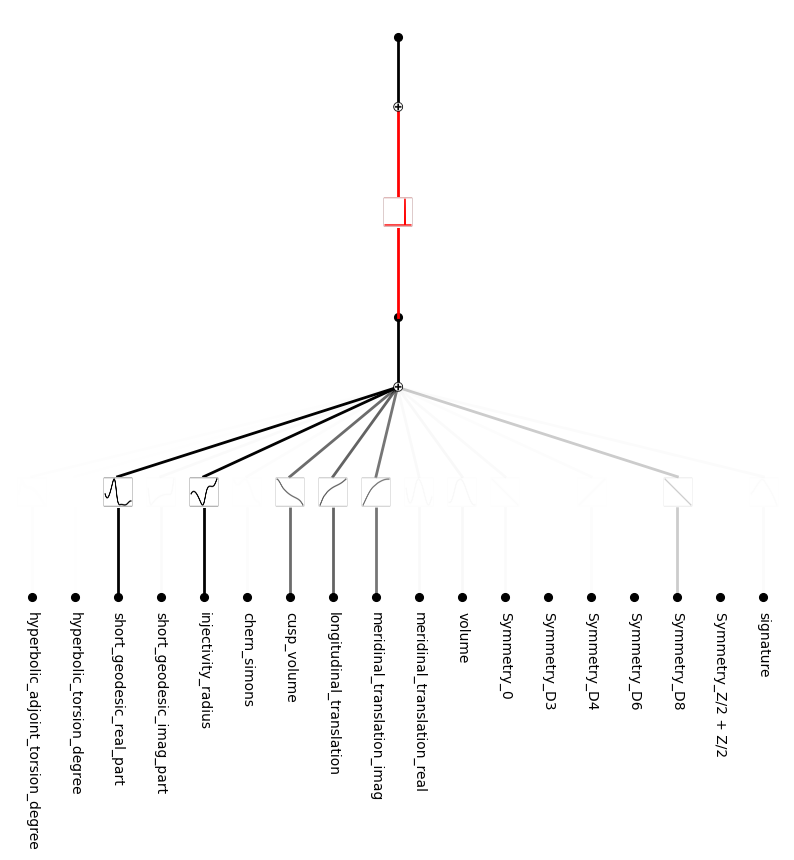

In [14]:
# seed = 2024
model.plot(scale=1.0)

n = 18
for i in range(n):
    plt.gcf().get_axes()[0].text(1/(2*n)+i/n-0.005,-0.02,df.keys()[1:][i], rotation=270, rotation_mode="anchor")

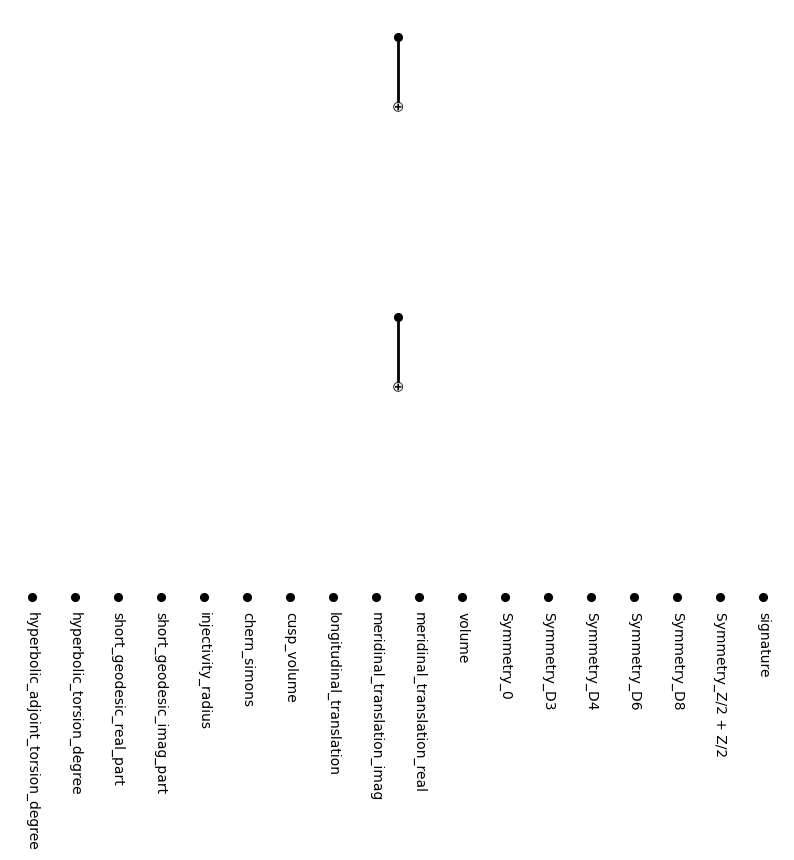

In [17]:
# seed = 0
model.plot(scale=1.0)

n = 18
for i in range(n):
    plt.gcf().get_axes()[0].text(1/(2*n)+i/n-0.005,-0.02,df.keys()[1:][i], rotation=270, rotation_mode="anchor")